In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [12]:
data_dir = r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\data"
caravan_dir = r"Caravan1.4"
attributes_dir = "attributes"
timeseries_dir = r"timeseries"
data_type = "csv"
caravan_data = "camels"

In [13]:
attrs_geo = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_other_{caravan_data}.{data_type}"))
attrs_geo['HUC'] = attrs_geo.gauge_id.str.split('_').str[1].str[:2]
attrs_geo['HUC_digits'] = attrs_geo['HUC'].astype(int)
# attrs_geo['HUC'] = attrs_geo.index.str.split('_').str[1].str[:2]
# attrs_geo_agg = attrs_geo.groupby('HUC')['area'].agg(['min', 'max', 'median', 'mean', 'var'])
# attrs_geo_agg.to_csv(r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\camels_stat_area_by_HUC.csv")
# attrs_geo.head()


In [14]:
attrs_geo_hysets = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, "hysets", f"attributes_other_hysets.{data_type}"))
attrs_geo_hysets['HUC'] = attrs_geo_hysets.gauge_id.str.split('_').str[1].str[:2]
attrs_geo_hysets_agg = attrs_geo.groupby('HUC')['area'].agg(['min', 'max', 'median', 'mean', 'var'])
attrs_geo_hysets_agg

,min,max,median,mean,var
HUC,,,,,
01,6.138014,3666.943011,187.283875,394.970886,3.408585e+05
02,10.326709,5921.059562,299.560552,527.795358,5.278777e+05
03,14.167080,2963.305977,293.103740,503.501037,3.387866e+05
04,11.927396,2975.893966,443.075785,705.876184,5.371972e+05
05,68.375544,8113.276774,876.867623,1417.522364,2.816466e+06
06,4.197622,25768.954367,741.147099,2117.554676,1.623741e+07
07,38.500460,6885.485961,712.216136,1349.528405,2.625620e+06
08,34.040092,3514.326061,503.714222,773.691997,4.860029e+05
09,11.616399,4811.784584,191.075901,423.019794,6.881724e+05


In [15]:
attrs_geo = attrs_geo.merge(attrs_geo_hysets_agg, how="left", on="HUC")

In [16]:
attrs_geo['diff_to_median'] = abs(attrs_geo['area'] - attrs_geo['median'])
top_closest = (attrs_geo.sort_values(by=['HUC', 'diff_to_median']).groupby('HUC').head(10))

In [17]:
top_closest.set_index("gauge_id",inplace=True)
top_closest

,gauge_name,country,gauge_lat,gauge_lon,area,HUC,HUC_digits,min,max,median,mean,var,diff_to_median
gauge_id,,,,,,,,,,,,,
camels_01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",United States of America,38.72833,-75.56186,187.283875,01,1,6.138014,3666.943011,187.283875,394.970886,340858.496804,0.000000
camels_01435000,NEVERSINK RIVER NEAR CLARYVILLE NY,United States of America,41.89009,-74.58988,183.200163,01,1,6.138014,3666.943011,187.283875,394.970886,340858.496804,4.083712
camels_01054200,"Wild River at Gilead, Maine",United States of America,44.39044,-70.97964,180.835783,01,1,6.138014,3666.943011,187.283875,394.970886,340858.496804,6.448092
camels_01440400,"Brodhead Creek near Analomink, PA",United States of America,41.08481,-75.21462,178.503303,01,1,6.138014,3666.943011,187.283875,394.970886,340858.496804,8.780571
camels_01057000,"Little Androscoggin River near South Paris, Maine",United States of America,44.30399,-70.53968,197.428264,01,1,6.138014,3666.943011,187.283875,394.970886,340858.496804,10.144389
...,...,...,...,...,...,...,...,...,...,...,...,...,...
camels_14020000,"UMATILLA RIVER ABOVE MEACHAM CREEK, NR GIBBON, OR",United States of America,45.71958,-118.32329,342.262647,14,14,7.898884,1740.840677,257.820823,324.997483,124198.828962,84.441824
camels_14308990,"COW CREEK ABV GALESVILLE RES, NR AZALEA, OR.",United States of America,42.82318,-123.12589,171.065321,14,14,7.898884,1740.840677,257.820823,324.997483,124198.828962,86.755502
camels_14216500,"MUDDY CREEK BELOW CLEAR CREEK NEAR COUGAR, WA",United States of America,46.07567,-121.99870,349.191320,14,14,7.898884,1740.840677,257.820823,324.997483,124198.828962,91.370497


In [18]:
top_closest.to_csv(r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\camels_with_similar_area_to_hysets.csv")

In [19]:
huc_list = [18, 20, 22, 26, 27, 28, 30, 36, 39, 90]

# Filter the DataFrame to only include rows where the HUC is in the huc_list
only_in_hysets = attrs_geo_hysets[attrs_geo_hysets['HUC'].astype(str).isin(map(str, huc_list))]
only_in_hysets.set_index("gauge_id", inplace=True)
only_in_hysets[["area", "HUC"]].to_csv(r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\only_in_hysets.csv")

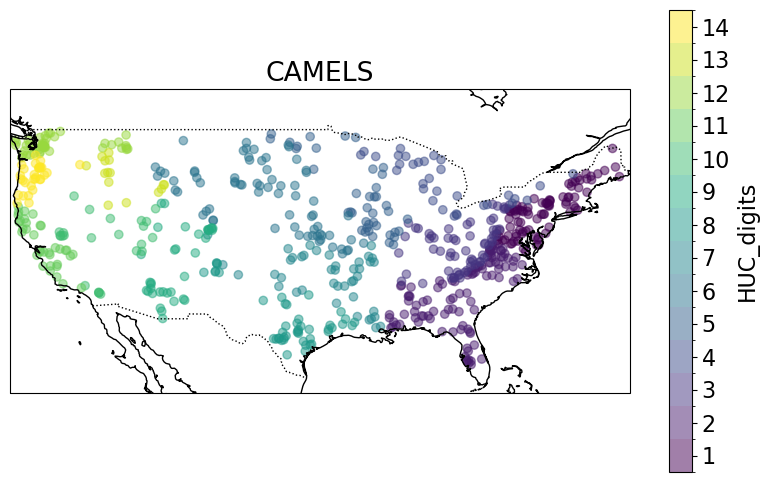

In [29]:
def plot_map(df, varname):

    # Set up the map
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Set extent to CONUS
    ax.set_extent([-124.85, -66.95, 24.396308, 49.384358])

    # Plotting the filtered data
    # Define the boundaries for each color and normalize
    n_colors = 14  # Number of discrete colors
    cmap = plt.get_cmap('viridis', n_colors)  # Get a colormap with n discrete colors
    boundaries = np.arange(0.5, 15.5, 1)  # Creates boundaries for 1 to 14
    norm = BoundaryNorm(boundaries, n_colors)

    scatter=ax.scatter(df['gauge_lon'], df['gauge_lat'], c=df[varname], alpha=0.5, cmap=cmap, norm=norm)

    # Create a colorbar
    cb = plt.colorbar(scatter, ax=ax, boundaries=boundaries, ticks=np.arange(1, 15), spacing='proportional')
    cb.set_label(varname)
    ax.set_title("CAMELS")

    # Show the plot
    plt.show()

from matplotlib.colors import ListedColormap, BoundaryNorm
plot_map(attrs_geo, "HUC_digits")